In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import subprocess
import tempfile
import os

In [2]:

BASE_DIR   = '/home/boussif/boussif/CM_inference/data/processed/Neu-SEA'
THRESHOLDS = [1.5, 2, 3, 4]
N_PEAKS    = 200
GENE_BED   = '/data/genome/homo_sapiens/GRCh38.102/Homo_sapiens.GRCh38.102.gtf.gene.body.bed'

CELL_TYPES = {
    'Glu':  {'out_dir': '../data/processed/results_aCM_AD_Glu'},
    'Gaba': {'out_dir': '../data/processed/results_aCM_AD_Gaba'},
}

for cfg in CELL_TYPES.values():
    os.makedirs(cfg['out_dir'], exist_ok=True)

def acm_path(cell_type, bg):
    return f'{BASE_DIR}/3.aCM_scores/{cell_type}/n_peaks_{N_PEAKS}/bg_threshold_{bg}/aCM_matrix/sign_corrected_aCM_matrix.bed'

def content_path(cell_type, bg):
    return f'{BASE_DIR}/1.clomics_CMs/{cell_type}/n_peaks_{N_PEAKS}/bg_threshold_{bg}/Neu-SEA/Neu-SEA_Clomics_CM_batches.content.txt'

def tracks_path(cell_type, bg):
    return f'{BASE_DIR}/1.clomics_CMs/{cell_type}/n_peaks_{N_PEAKS}/bg_threshold_{bg}/Neu-SEA/Neu-SEA_Clomics_CM.tracks.bed'

def run_correlation(acm_df, phenotype):
    """Spearman correlation of each CM row against a phenotype vector (aligned)."""
    results = []
    common = acm_df.columns.intersection(phenotype.index)
    ph = phenotype.loc[common]
    for cm_id, row in acm_df[common].iterrows():
        r, p = stats.spearmanr(row.values, ph.values)
        results.append({'CM': cm_id, 'rho': r, 'pval': p})
    df = pd.DataFrame(results).set_index('CM')
    reject, padj, _, _ = multipletests(df['pval'], method='fdr_bh')
    df['padj'] = padj
    return df


In [3]:
# --- Load metadata ---
meta_df = pd.read_csv('../data/metadata/metadata.txt', sep='\t', index_col=0)
pps = meta_df['Continuous_Pseudo-progression_Score'].dropna()
cog_status = meta_df['Cognitive_Status'].dropna()
print(f"Donors avec PPS: {len(pps)}")
print(f"Cognitive status: {cog_status.value_counts().to_dict()}")

Donors avec PPS: 73
Cognitive status: {'No dementia': 41, 'Dementia': 32, 'Reference': 2}


In [4]:
# --- Load all aCM matrices and run correlations ---
# all_acm_dicts : cell_type -> {bg -> acm DataFrame}
# all_res_dicts : cell_type -> {bg -> correlation results DataFrame}
all_acm_dicts = {}
all_res_dicts = {}

for cell_type, cfg in CELL_TYPES.items():
    print(f"\n{'='*60}")
    print(f"=== {cell_type} ===")
    acm_dict = {}
    res_dict = {}
    for bg in THRESHOLDS:
        path = acm_path(cell_type, bg)
        if not os.path.exists(path):
            print(f"  bg={bg}: MANQUANT ({path})")
            continue
        acm_df = pd.read_csv(path, sep='\t', index_col=0)
        acm_dict[bg] = acm_df
        res_dict[bg] = run_correlation(acm_df, pps)
        n_sig   = (res_dict[bg]['padj'] < 0.05).sum()
        n_open  = ((res_dict[bg]['padj'] < 0.05) & (res_dict[bg]['rho'] > 0)).sum()
        n_close = ((res_dict[bg]['padj'] < 0.05) & (res_dict[bg]['rho'] < 0)).sum()
        print(f"  bg={bg}: {len(acm_df)} CMs | FDR<0.05: {n_sig} (↑{n_open} ↓{n_close})")
    all_acm_dicts[cell_type] = acm_dict
    all_res_dicts[cell_type] = res_dict


=== Glu ===
  bg=1.5: 15568 CMs | FDR<0.05: 2757 (↑1380 ↓1377)
  bg=2: 17516 CMs | FDR<0.05: 3874 (↑2277 ↓1597)
  bg=3: 13868 CMs | FDR<0.05: 3643 (↑2565 ↓1078)
  bg=4: 8492 CMs | FDR<0.05: 2644 (↑1914 ↓730)

=== Gaba ===
  bg=1.5: 11603 CMs | FDR<0.05: 2973 (↑1778 ↓1195)
  bg=2: 10456 CMs | FDR<0.05: 2887 (↑1845 ↓1042)
  bg=3: 6572 CMs | FDR<0.05: 1976 (↑1427 ↓549)
  bg=4: 3813 CMs | FDR<0.05: 1271 (↑973 ↓298)


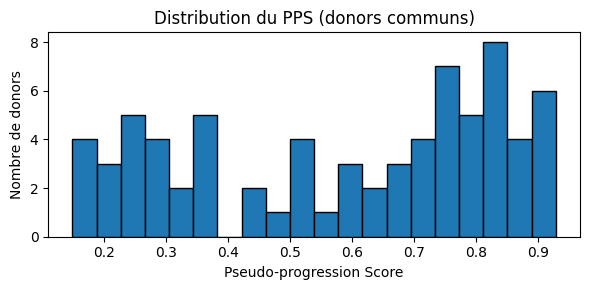

In [5]:

ref_bg = THRESHOLDS[0]
ref_acm = next(iter(all_acm_dicts.values()))  # premiers donors disponibles
pps_aligned = pps.loc[pps.index.intersection(ref_acm[ref_bg].columns)]

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(pps_aligned.values, bins=20, edgecolor='black')
ax.set_xlabel('Pseudo-progression Score')
ax.set_ylabel('Nombre de donors')
ax.set_title('Distribution du PPS (donors communs)')
plt.tight_layout()
plt.savefig(f'{CELL_TYPES["Glu"]["out_dir"]}/pps_distribution.png', dpi=150)
plt.show()


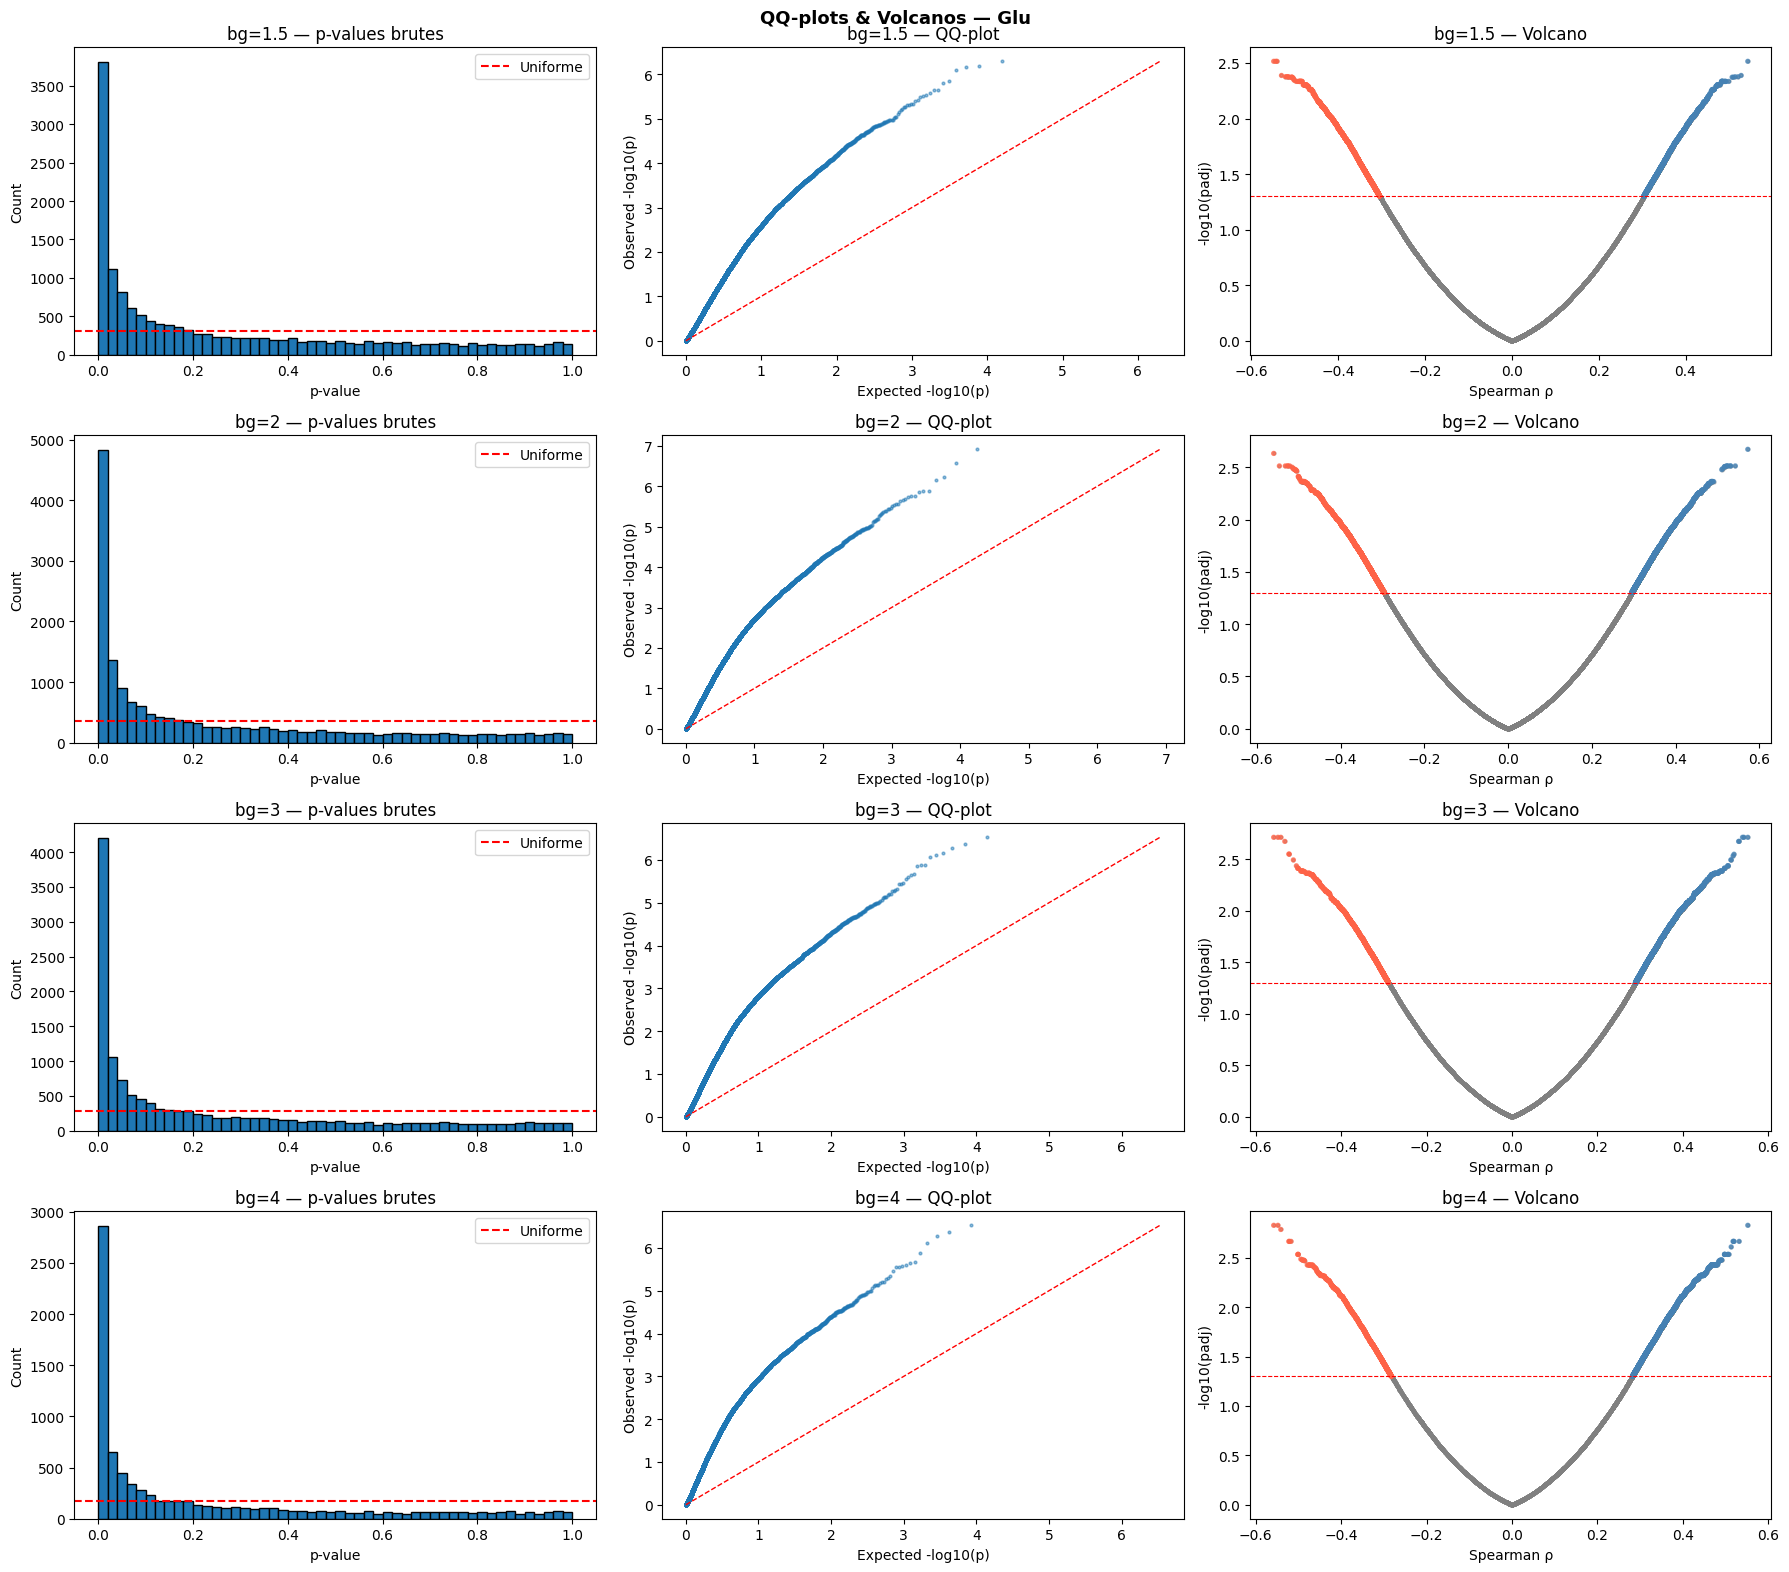

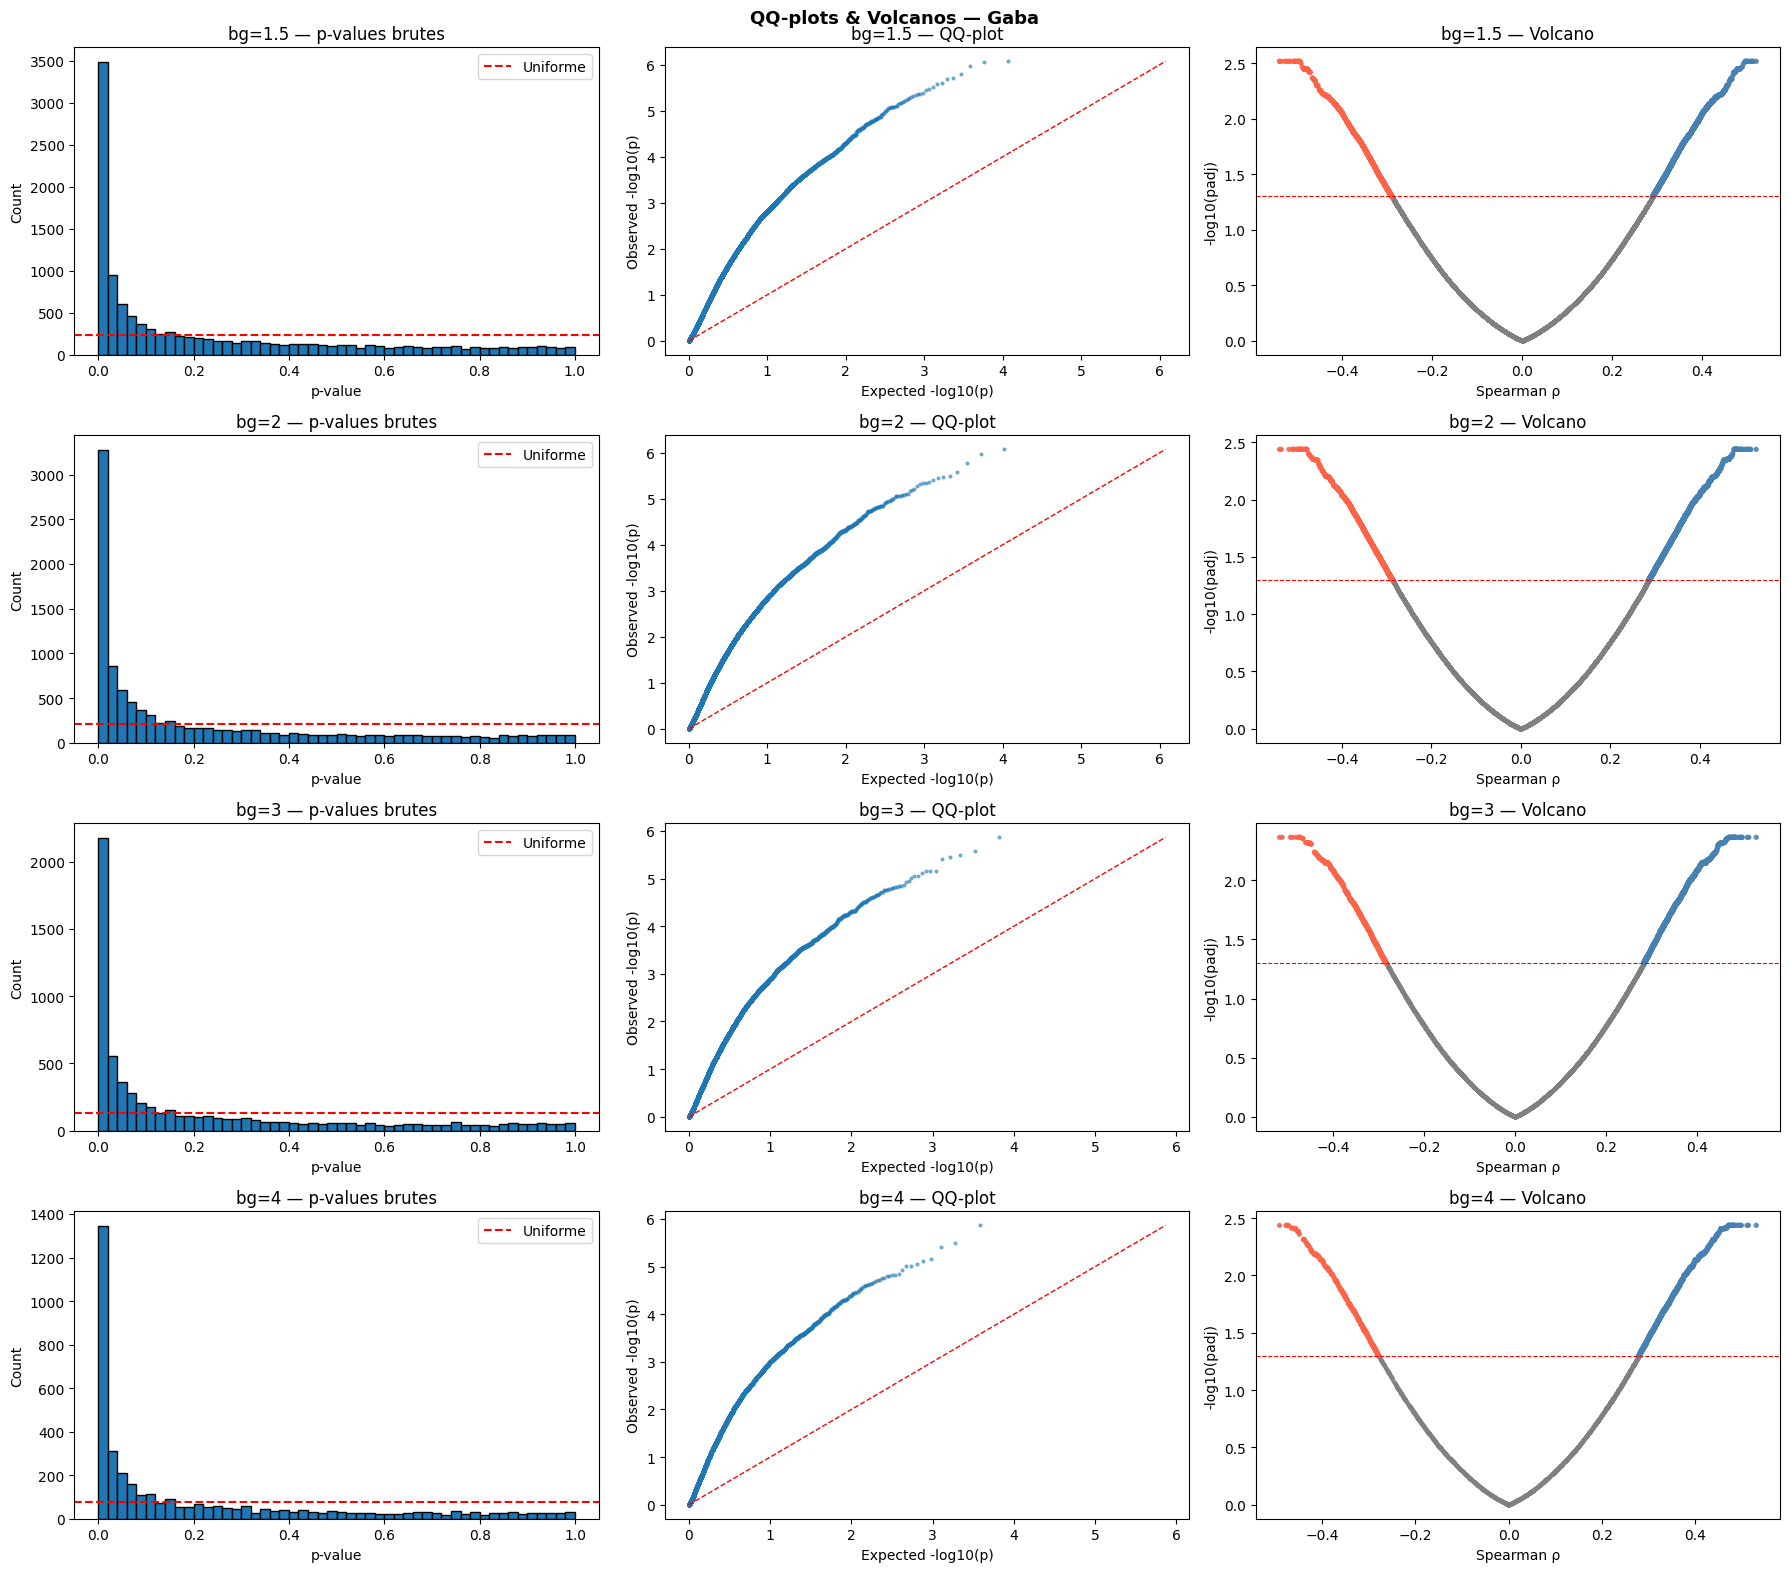

In [6]:

# ============================================================================
# QQ-plots & p-value distributions — all thresholds × all cell types
# ============================================================================
for cell_type, cfg in CELL_TYPES.items():
    out_dir  = cfg['out_dir']
    res_dict = all_res_dicts[cell_type]
    bgs      = list(res_dict.keys())
    if not bgs:
        print(f"{cell_type}: aucun résultat disponible")
        continue

    fig, axes = plt.subplots(len(bgs), 3, figsize=(18, 4 * len(bgs)))
    if len(bgs) == 1:
        axes = axes[np.newaxis, :]
    fig.suptitle(f'QQ-plots & Volcanos — {cell_type}', fontsize=13, fontweight='bold')

    for i, bg in enumerate(bgs):
        res = res_dict[bg]

        # P-value distribution
        axes[i, 0].hist(res['pval'], bins=50, edgecolor='black')
        axes[i, 0].axhline(y=len(res)/50, color='red', linestyle='--', label='Uniforme')
        axes[i, 0].set_xlabel('p-value')
        axes[i, 0].set_ylabel('Count')
        axes[i, 0].set_title(f'bg={bg} — p-values brutes')
        axes[i, 0].legend()

        # QQ-plot
        observed = -np.log10(np.sort(res['pval'].values))
        expected = -np.log10(np.linspace(1/len(res), 1, len(res)))
        axes[i, 1].scatter(expected, observed, s=4, alpha=0.5)
        max_val = max(expected.max(), observed.max())
        axes[i, 1].plot([0, max_val], [0, max_val], 'r--', linewidth=1)
        axes[i, 1].set_xlabel('Expected -log10(p)')
        axes[i, 1].set_ylabel('Observed -log10(p)')
        axes[i, 1].set_title(f'bg={bg} — QQ-plot')

        # Volcano plot
        axes[i, 2].scatter(res['rho'], -np.log10(res['padj']), s=4, alpha=0.5, c='grey')
        sig = res[res['padj'] < 0.05]
        if len(sig) > 0:
            colors = ['steelblue' if r > 0 else 'tomato' for r in sig['rho']]
            axes[i, 2].scatter(sig['rho'], -np.log10(sig['padj']), s=8, alpha=0.7, c=colors)
        axes[i, 2].axhline(-np.log10(0.05), color='red', linestyle='--', linewidth=0.8)
        axes[i, 2].set_xlabel('Spearman ρ')
        axes[i, 2].set_ylabel('-log10(padj)')
        axes[i, 2].set_title(f'bg={bg} — Volcano')

    plt.tight_layout()
    plt.savefig(f'{out_dir}/all_thresholds_qqplot_volcano.png', dpi=150)
    plt.show()


In [7]:

# ============================================================================
# Seuils alternatifs — tableau récapitulatif par type cellulaire
# ============================================================================
for cell_type, cfg in CELL_TYPES.items():
    out_dir  = cfg['out_dir']
    res_dict = all_res_dicts[cell_type]
    print(f"\n{'='*50}\n=== {cell_type} ===")

    rows = []
    for bg, res in res_dict.items():
        row = {'bg_threshold': bg, 'total_CMs': len(res)}
        for seuil in [0.1, 0.05, 0.01, 0.001]:
            row[f'padj<{seuil}'] = (res['padj'] < seuil).sum()
            row[f'pval<{seuil}'] = (res['pval'] < seuil).sum()
        rows.append(row)

    summary_table = pd.DataFrame(rows).set_index('bg_threshold')
    print(summary_table.to_string())
    summary_table.to_csv(f'{out_dir}/threshold_summary.csv')



=== Glu ===
              total_CMs  padj<0.1  pval<0.1  padj<0.05  pval<0.05  padj<0.01  pval<0.01  padj<0.001  pval<0.001
bg_threshold                                                                                                   
1.5               15568      4337      6870       2757       5342        430       2900           0         956
2.0               17516      5799      8356       3874       6673        643       3730           0        1210
3.0               13868      5121      6972       3643       5664        763       3308           0        1092
4.0                8492      3578      4584       2644       3751        728       2282           0         784

=== Gaba ===
              total_CMs  padj<0.1  pval<0.1  padj<0.05  pval<0.05  padj<0.01  pval<0.01  padj<0.001  pval<0.001
bg_threshold                                                                                                   
1.5               11603      4364      5866       2973       4766        670 

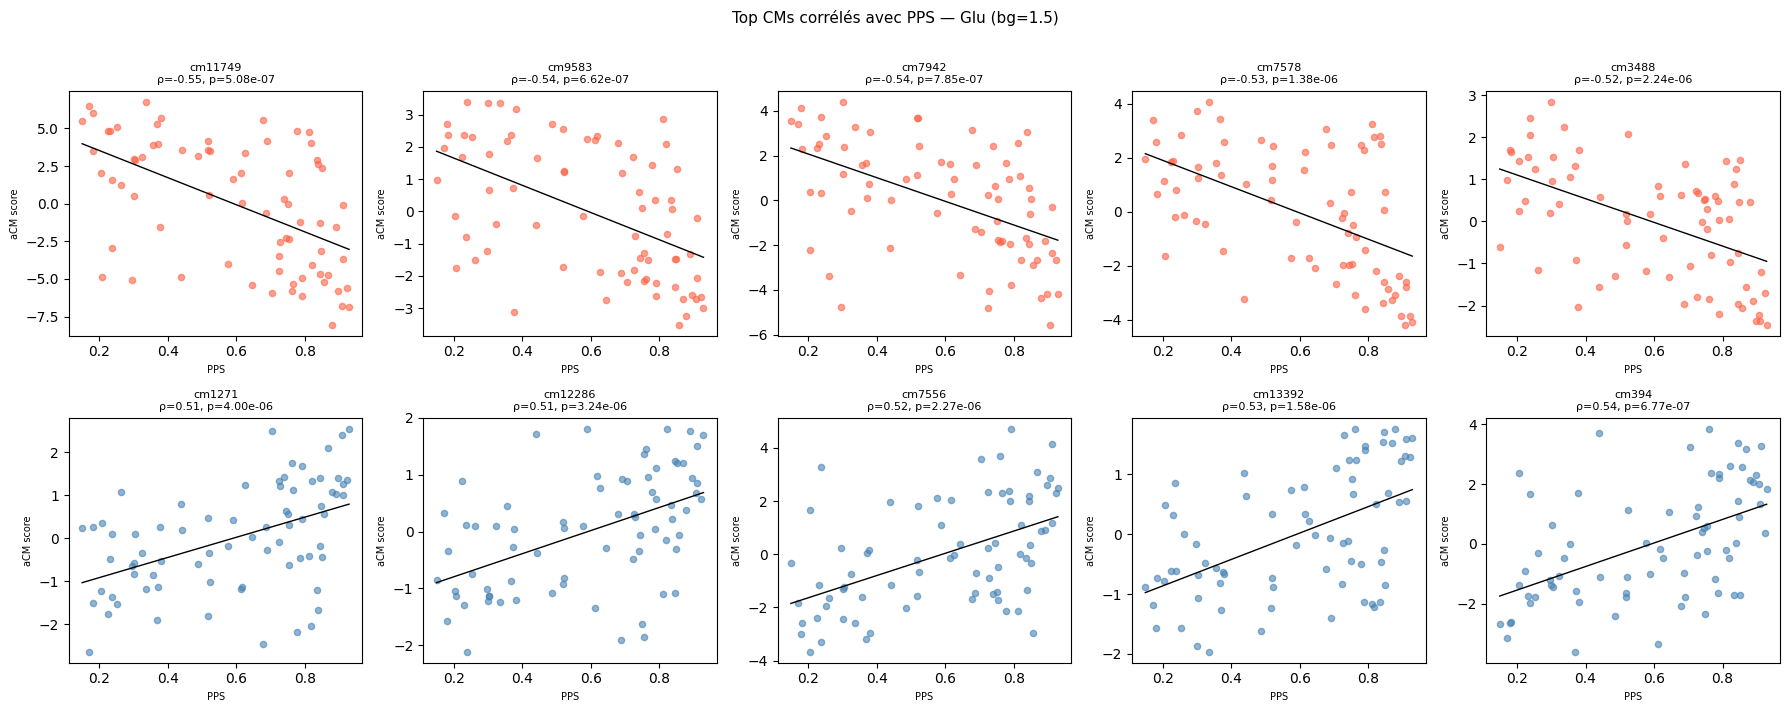

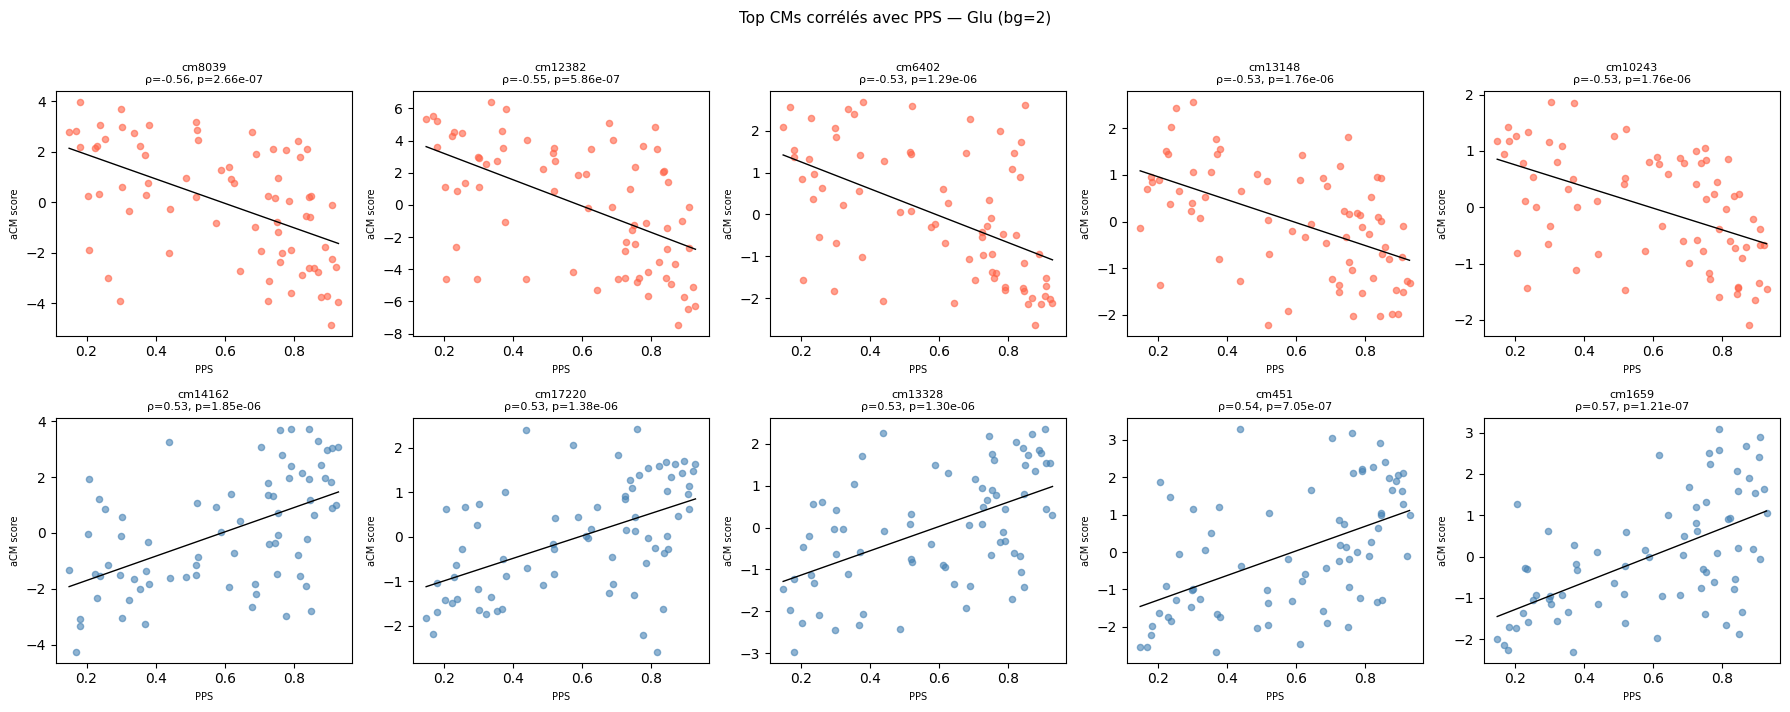

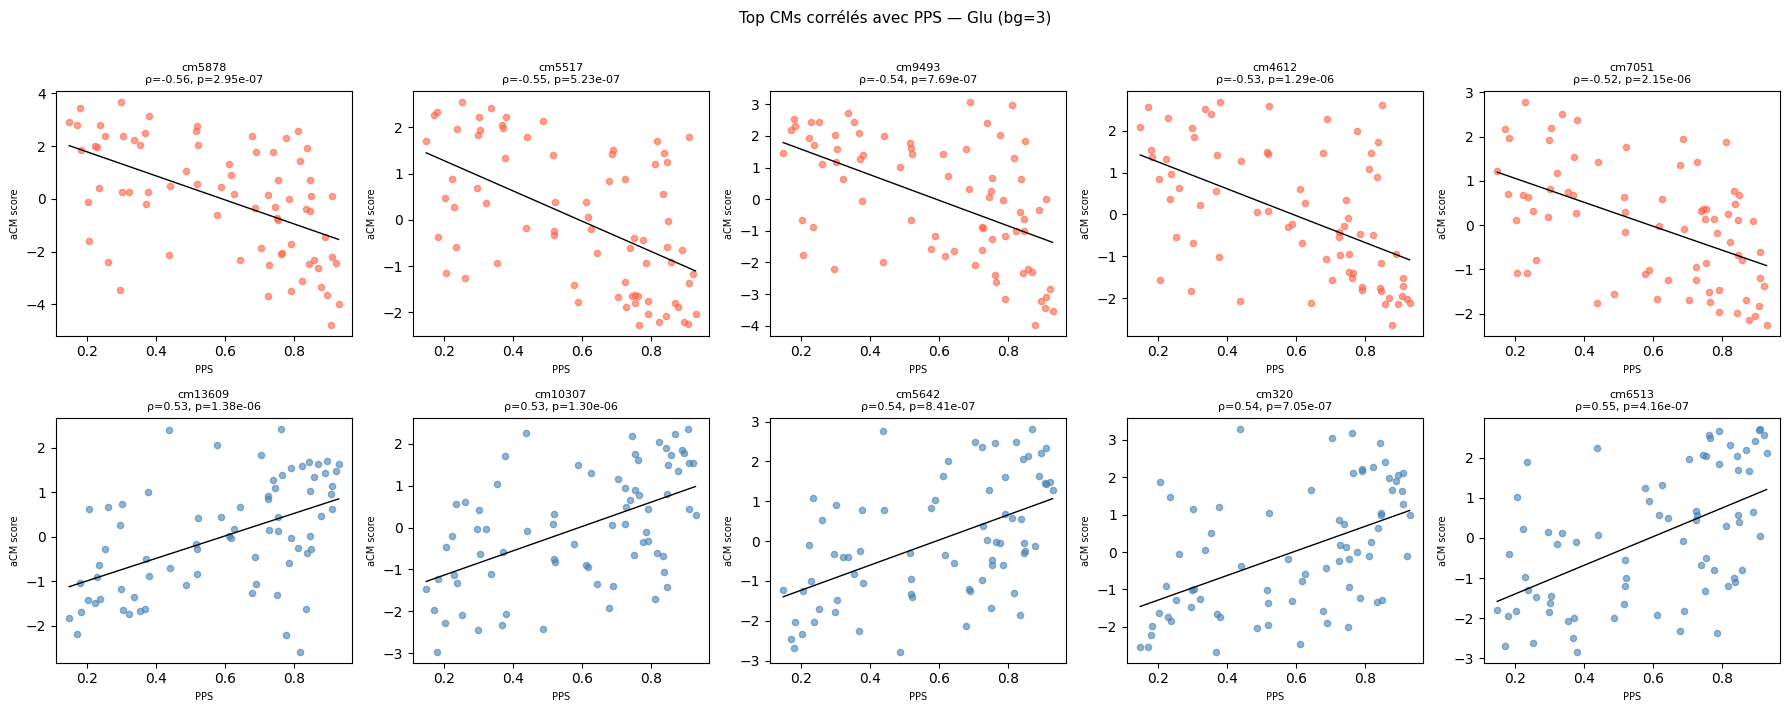

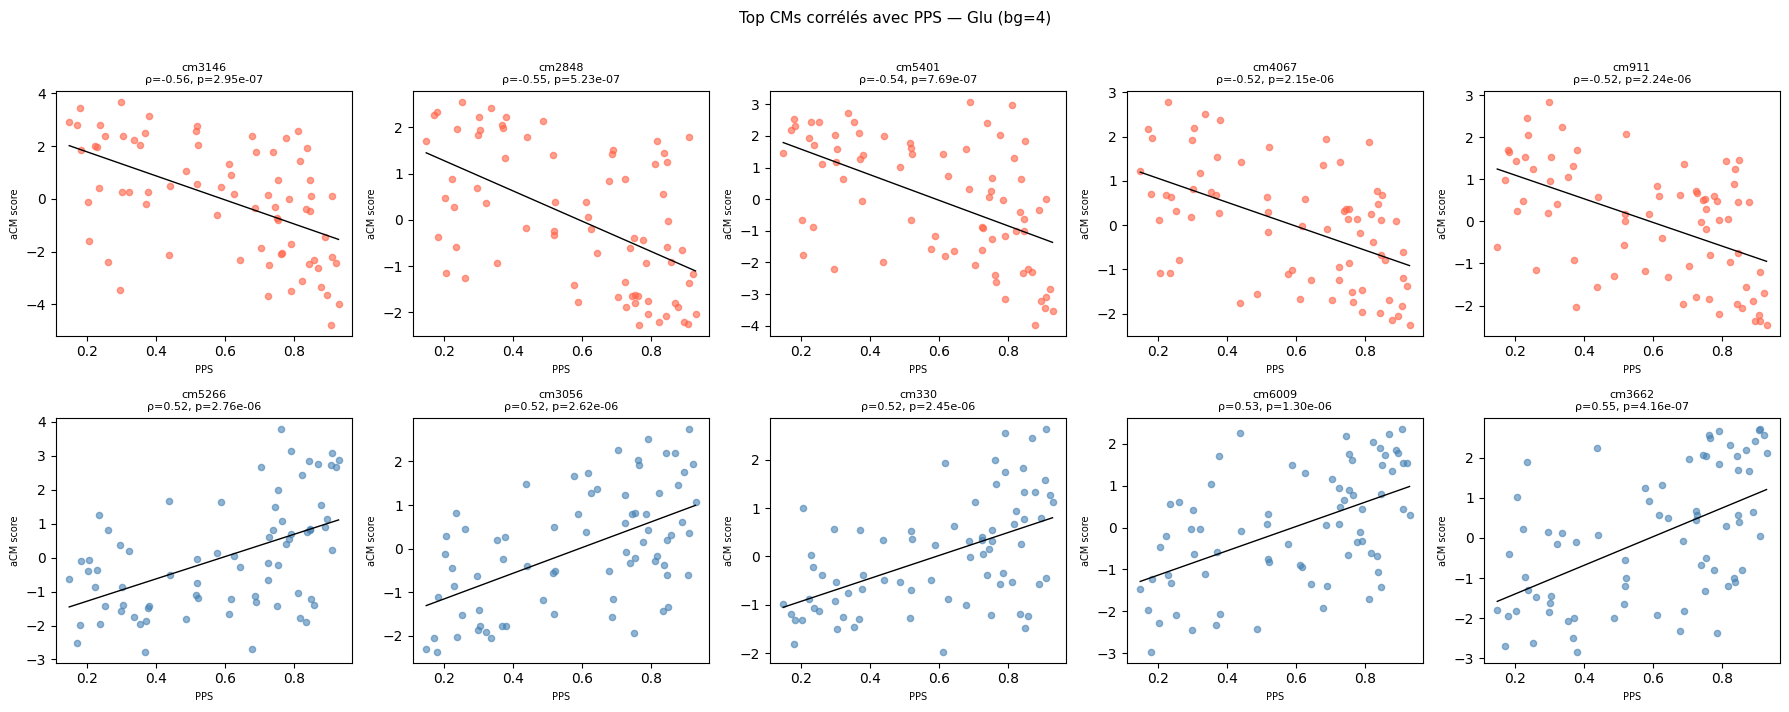

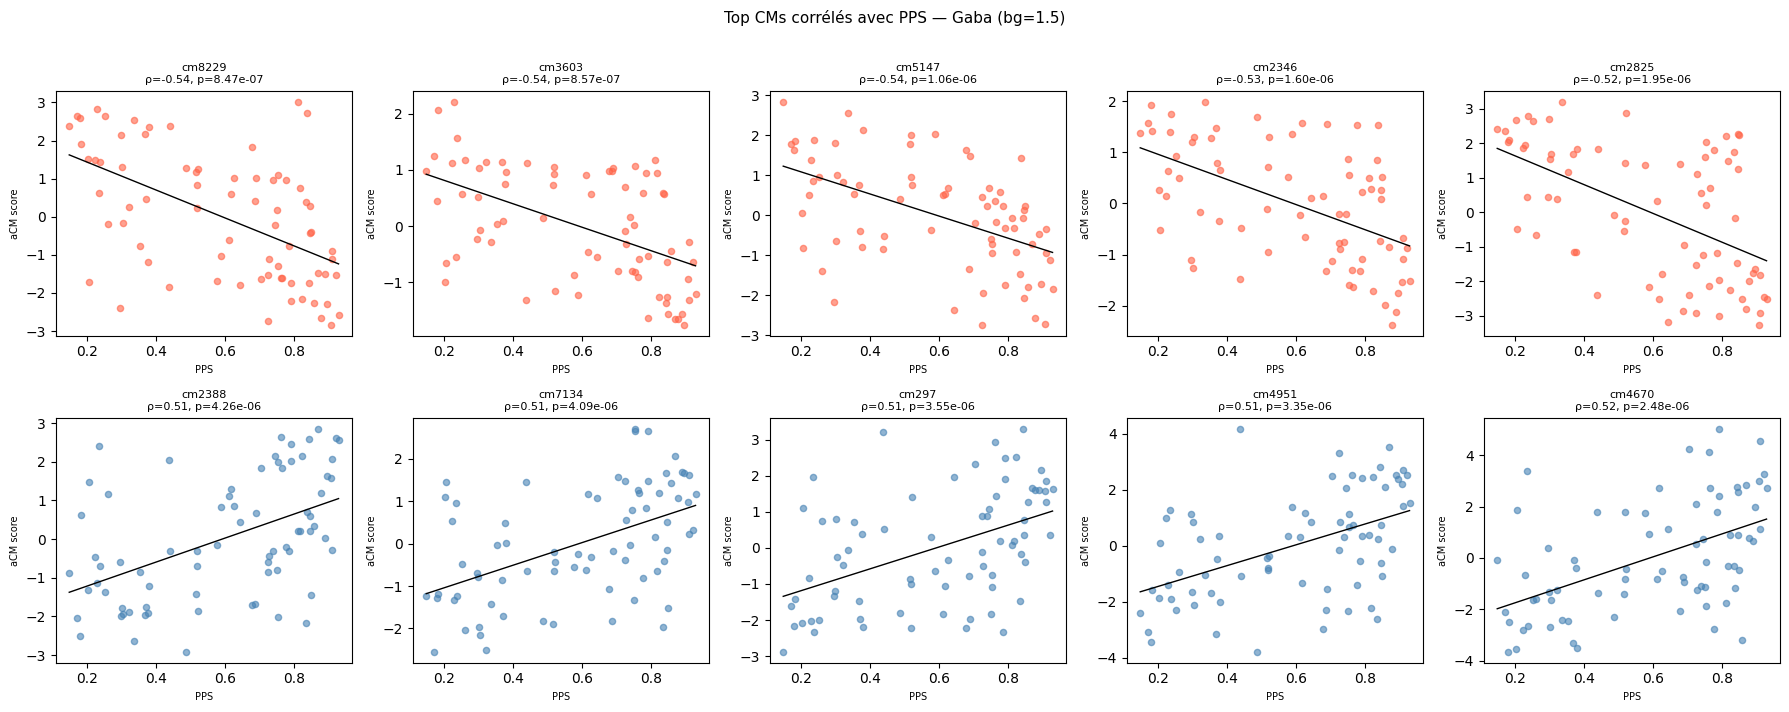

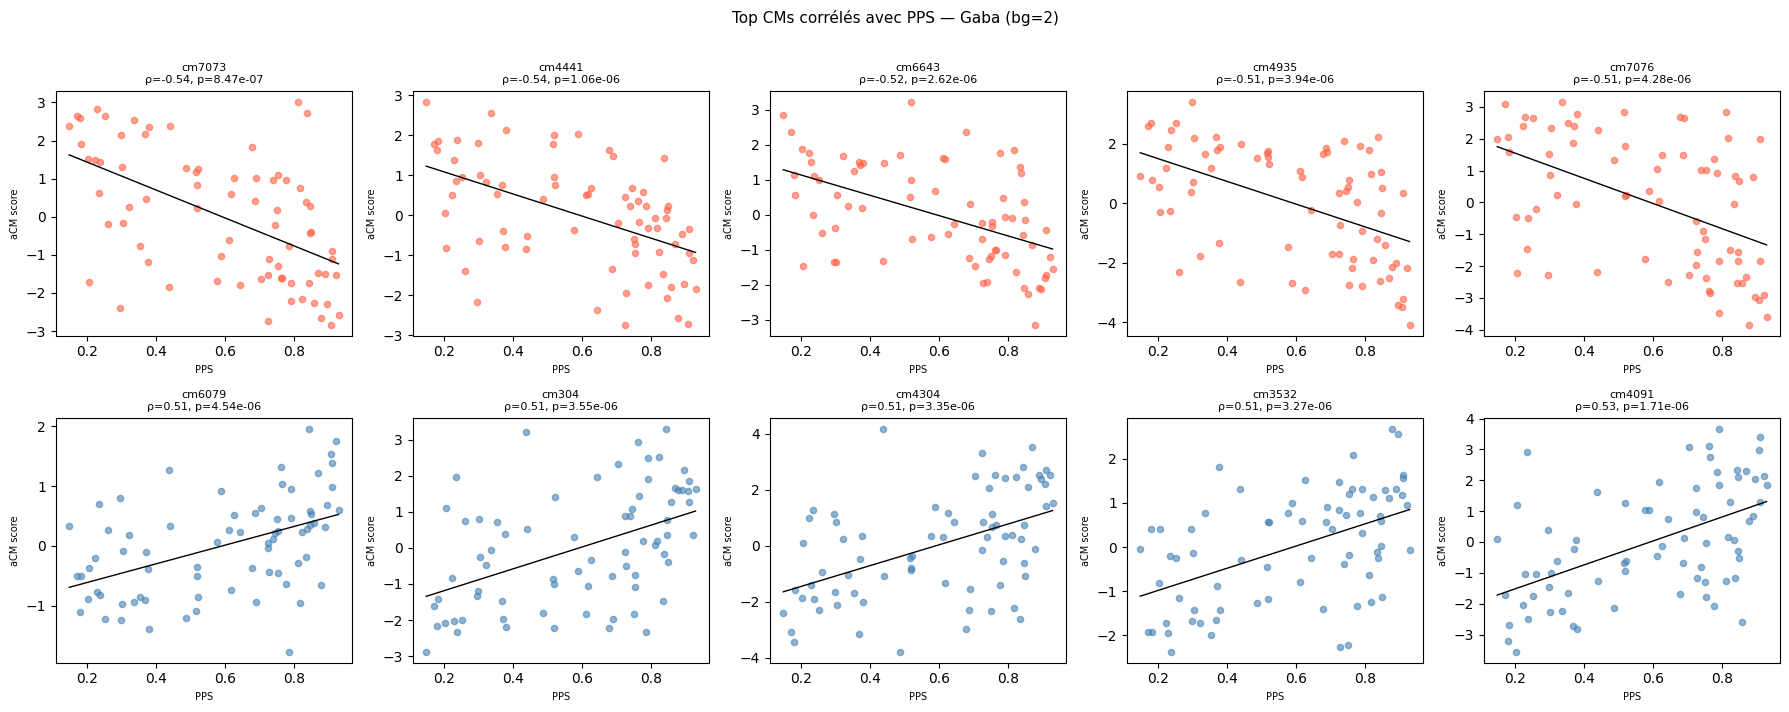

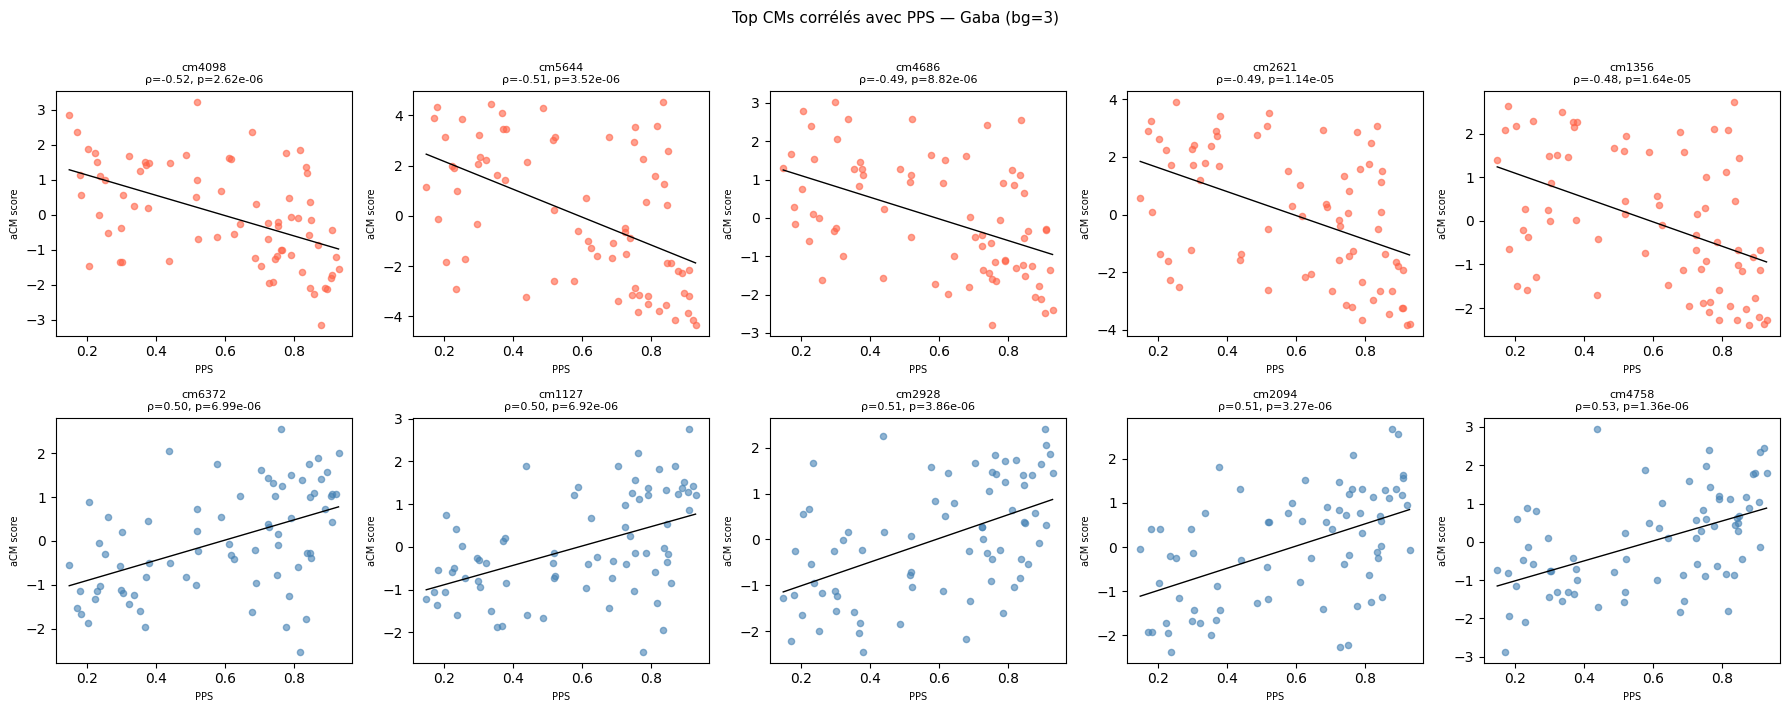

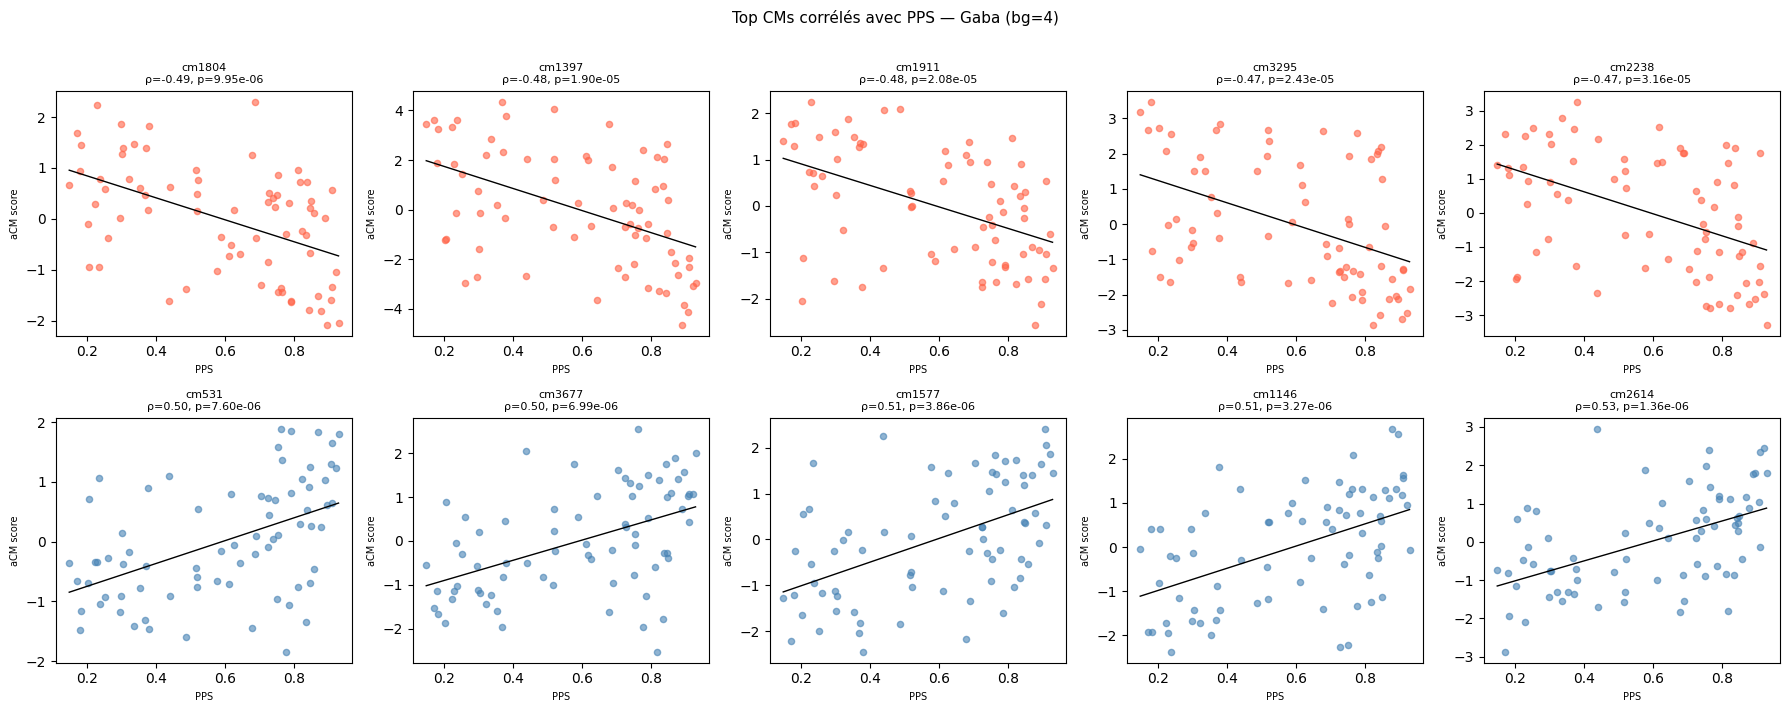

In [8]:

# ============================================================================
# Top CMs scatter plots — per threshold × per cell type
# ============================================================================
for cell_type, cfg in CELL_TYPES.items():
    out_dir  = cfg['out_dir']
    acm_dict = all_acm_dicts[cell_type]
    res_dict = all_res_dicts[cell_type]

    for bg, res in res_dict.items():
        acm_df    = acm_dict[bg]
        candidates = res[res['padj'] < 0.05].sort_values('rho')
        common_col = acm_df.columns.intersection(pps_aligned.index)
        pps_bg     = pps_aligned.loc[common_col]

        if len(candidates) < 10:
            top_closing = candidates.head(min(5, len(candidates))).index.tolist()
            top_opening = candidates.tail(min(5, len(candidates))).index.tolist()
        else:
            top_closing = candidates.head(5).index.tolist()
            top_opening = candidates.tail(5).index.tolist()

        top_cms = list(dict.fromkeys(top_closing + top_opening))
        n_cms   = len(top_cms)
        if n_cms == 0:
            print(f"{cell_type} bg={bg}: No CMs with padj < 0.05")
            continue

        ncols = min(5, n_cms)
        nrows = (n_cms + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(3.6 * ncols, 3.5 * nrows), squeeze=False)

        for i, cm_id in enumerate(top_cms):
            ax  = axes[i // ncols][i % ncols]
            x   = pps_bg.values
            y   = acm_df.loc[cm_id, pps_bg.index].values
            rho = candidates.loc[cm_id, 'rho']
            p   = candidates.loc[cm_id, 'pval']
            ax.scatter(x, y, alpha=0.6, s=20, color='steelblue' if rho > 0 else 'tomato')
            z = np.polyfit(x, y, 1)
            xline = np.linspace(x.min(), x.max(), 100)
            ax.plot(xline, np.poly1d(z)(xline), color='black', linewidth=1)
            ax.set_title(f'{cm_id}\nρ={rho:.2f}, p={p:.2e}', fontsize=8)
            ax.set_xlabel('PPS', fontsize=7)
            ax.set_ylabel('aCM score', fontsize=7)

        for j in range(n_cms, nrows * ncols):
            axes[j // ncols][j % ncols].axis('off')

        plt.suptitle(f'Top CMs corrélés avec PPS — {cell_type} (bg={bg})', fontsize=11, y=1.01)
        plt.tight_layout()
        plt.savefig(f'{out_dir}/top_cms_scatter_bg{bg}.png', dpi=150)
        plt.show()


In [9]:

# all_sig_cms : cell_type -> {bg -> sig DataFrame}
all_sig_cms = {}

for cell_type, cfg in CELL_TYPES.items():
    res_dict = all_res_dicts[cell_type]
    sig_cms  = {}
    for bg, res in res_dict.items():
        sig = res[(res['padj'] < 0.05) & (abs(res['rho']) > 0.3)]
        sig_cms[bg] = sig
    all_sig_cms[cell_type] = sig_cms

    if sig_cms:
        union_sig = pd.concat(sig_cms.values()).index.unique()
    else:
        union_sig = pd.Index([])
    print(f"{cell_type} — Union sig CMs (padj<0.05, |rho|>0.3): {len(union_sig)}")
    for bg, sig in sig_cms.items():
        print(f"  bg={bg}: {len(sig)} sig")


Glu — Union sig CMs (padj<0.05, |rho|>0.3): 9175
  bg=1.5: 2757 sig
  bg=2: 3715 sig
  bg=3: 3297 sig
  bg=4: 2278 sig
Gaba — Union sig CMs (padj<0.05, |rho|>0.3): 6089
  bg=1.5: 2685 sig
  bg=2: 2543 sig
  bg=3: 1704 sig
  bg=4: 1081 sig


In [10]:

for cell_type, cfg in CELL_TYPES.items():
    out_dir  = cfg['out_dir']
    res_dict = all_res_dicts[cell_type]
    sig_cms  = all_sig_cms[cell_type]

    if not sig_cms:
        print(f"{cell_type}: aucun CM significatif")
        continue

    union_sig = pd.concat(sig_cms.values()).index.unique()

    union_sig_df = pd.DataFrame()
    for bg, res in res_dict.items():
        available = union_sig.intersection(res.index)
        bg_df = res.loc[available].copy()
        bg_df['bg'] = bg
        union_sig_df = pd.concat([union_sig_df, bg_df])

    union_sig_df = union_sig_df[~union_sig_df.index.duplicated(keep='first')]
    union_sig_df.to_csv(f'{out_dir}/sig_cms_padj01_rho03.csv')
    print(f"{cell_type} ✅ {union_sig_df.shape[0]} CMs sig sauvegardés → {out_dir}/sig_cms_padj01_rho03.csv")
    print(union_sig_df.head())


Glu ✅ 9175 CMs sig sauvegardés → ../data/processed/results_aCM_AD_Glu/sig_cms_padj01_rho03.csv
           rho      pval      padj   bg
CM                                     
cm0   0.315859  0.006485  0.041806  1.5
cm2   0.349562  0.002435  0.025083  1.5
cm4  -0.454122  0.000054  0.006200  1.5
cm5  -0.379242  0.000937  0.015991  1.5
cm22  0.313834  0.006855  0.043137  1.5
Gaba ✅ 6089 CMs sig sauvegardés → ../data/processed/results_aCM_AD_Gaba/sig_cms_padj01_rho03.csv
           rho      pval      padj   bg
CM                                     
cm0   0.315859  0.006485  0.033458  1.5
cm1   0.336604  0.003594  0.023373  1.5
cm4   0.302604  0.009264  0.041170  1.5
cm6  -0.454122  0.000054  0.005058  1.5
cm14  0.359743  0.001772  0.016037  1.5


In [11]:

# all_cm_peaks : cell_type -> {cm_bg_key -> [peaks]}
all_cm_peaks = {}

for cell_type, cfg in CELL_TYPES.items():
    sig_cms  = all_sig_cms[cell_type]
    cm_peaks = {}

    print(f"\n{'='*50}\n=== {cell_type} ===")
    for bg, sig_this_bg_df in sig_cms.items():
        sig_this_bg = sig_this_bg_df.index
        cpath = content_path(cell_type, bg)
        print(f"\n--- bg={bg} ---")
        if not os.path.exists(cpath):
            print("MANQUANT")
            continue

        df_content = pd.read_csv(cpath, sep='\t', header=None,
                                 names=['CM_full', 'nb_peaks', 'peaks_str'])
        df_content['CM'] = df_content['CM_full'].str.split('_').str[0]
        print(f"Sig CE bg: {len(sig_this_bg)}")

        found = 0
        for cm in sig_this_bg:
            if cm in df_content['CM'].values:
                peaks_str  = df_content[df_content['CM'] == cm]['peaks_str'].iloc[0]
                peaks_list = [p.strip() for p in peaks_str.split(',')]
                cm_peaks[f"{cm}_bg{bg}"] = peaks_list
                found += 1
        print(f"Match content: {found}/{len(sig_this_bg)}")

    all_cm_peaks[cell_type] = cm_peaks
    print(f"\n✅ {cell_type} TOTAL: {len(cm_peaks)} CMs (bg-spécifiques)")



=== Glu ===

--- bg=1.5 ---
Sig CE bg: 2757


Match content: 2757/2757

--- bg=2 ---
Sig CE bg: 3715
Match content: 3715/3715

--- bg=3 ---
Sig CE bg: 3297
Match content: 3297/3297

--- bg=4 ---
Sig CE bg: 2278
Match content: 2278/2278

✅ Glu TOTAL: 12047 CMs (bg-spécifiques)

=== Gaba ===

--- bg=1.5 ---
Sig CE bg: 2685
Match content: 2685/2685

--- bg=2 ---
Sig CE bg: 2543
Match content: 2543/2543

--- bg=3 ---
Sig CE bg: 1704
Match content: 1704/1704

--- bg=4 ---
Sig CE bg: 1081
Match content: 1081/1081

✅ Gaba TOTAL: 8013 CMs (bg-spécifiques)


In [12]:

# BED de tous les peaks — un fichier par type cellulaire
for cell_type, cfg in CELL_TYPES.items():
    out_dir  = cfg['out_dir']
    cm_peaks = all_cm_peaks[cell_type]
    all_peaks_bed = []

    for cm_bg, peaks_list in cm_peaks.items():
        cm_id = cm_bg.split('_bg')[0]
        for peak in peaks_list:
            parts = peak.split(':')
            chrom = parts[1]
            start = int(parts[2])
            end   = int(parts[3])
            all_peaks_bed.append([chrom, start, end, cm_id, cm_bg])

    if not all_peaks_bed:
        print(f"{cell_type}: aucun peak à exporter")
        continue

    peaks_df = pd.DataFrame(all_peaks_bed, columns=['chr', 'start', 'end', 'CM', 'CM_bg'])
    peaks_df.to_csv(f'{out_dir}/sig_cms_all_peaks.bed', sep='\t', index=False, header=False)
    print(f"{cell_type} ✅ BED: {len(peaks_df)} peaks pour {len(cm_peaks)} CMs")
    print(peaks_df.head())


Glu ✅ BED: 107848 peaks pour 12047 CMs
    chr    start      end   CM      CM_bg
0  chr1   629906   629979  cm0  cm0_bg1.5
1  chr1   633985   634069  cm0  cm0_bg1.5
2  chr1   869620   870513  cm2  cm2_bg1.5
3  chr1  1777602  1785758  cm2  cm2_bg1.5
4  chr1  1246353  1246993  cm2  cm2_bg1.5
Gaba ✅ BED: 73348 peaks pour 8013 CMs
    chr    start      end   CM      CM_bg
0  chr1   629906   629979  cm0  cm0_bg1.5
1  chr1   633985   634069  cm0  cm0_bg1.5
2  chr1   869620   870513  cm1  cm1_bg1.5
3  chr1  1557930  1559280  cm1  cm1_bg1.5
4  chr1  3228404  3228657  cm1  cm1_bg1.5


In [13]:

# Bedtools intersect peaks → gènes — un fichier par type cellulaire
for cell_type, cfg in CELL_TYPES.items():
    out_dir    = cfg['out_dir']
    peaks_raw  = f'{out_dir}/sig_cms_all_peaks.bed'
    peaks_fixed = f'{out_dir}/sig_cms_all_peaks_FIXED.bed'
    genes_bed   = f'{out_dir}/sig_cms_peaks_to_genes.bed'

    if not os.path.exists(peaks_raw):
        print(f"{cell_type}: fichier BED manquant, ignoré")
        continue

    # Fix chr prefix
    peaks_df = pd.read_csv(peaks_raw, sep='\t', header=None,
                           names=['chr', 'start', 'end', 'CM', 'CM_bg'])
    peaks_df['chr'] = peaks_df['chr'].str.replace('chr', '', regex=False)
    peaks_df.to_csv(peaks_fixed, sep='\t', index=False, header=False)
    print(f"{cell_type} — chr fixed ({len(peaks_df)} peaks)")

    cmd = f"bedtools intersect -wa -wb -a {peaks_fixed} -b {GENE_BED} > {genes_bed}"
    subprocess.run(cmd, shell=True)
    n_lines = int(subprocess.run(f"wc -l < {genes_bed}", shell=True, capture_output=True, text=True).stdout.strip())
    print(f"{cell_type} ✅ {n_lines} overlaps → {genes_bed}")


Glu — chr fixed (107848 peaks)
Glu ✅ 107098 overlaps → ../data/processed/results_aCM_AD_Glu/sig_cms_peaks_to_genes.bed
Gaba — chr fixed (73348 peaks)
Gaba ✅ 75771 overlaps → ../data/processed/results_aCM_AD_Gaba/sig_cms_peaks_to_genes.bed


In [14]:

# Parse gene overlaps → table propre — par type cellulaire
all_results = {}

for cell_type, cfg in CELL_TYPES.items():
    out_dir   = cfg['out_dir']
    genes_bed = f'{out_dir}/sig_cms_peaks_to_genes.bed'

    if not os.path.exists(genes_bed):
        print(f"{cell_type}: fichier gene BED manquant, ignoré")
        continue

    gene_hits = pd.read_csv(genes_bed, sep='\t', header=None,
                            names=['chr_p', 'start_p', 'end_p', 'CM', 'CM_bg',
                                   'chr_g', 'start_g', 'end_g', 'gene_id', 'score', 'strand'])
    gene_hits['gene_name'] = gene_hits['gene_id'].str.split('~').str[1]
    gene_hits['ensembl']   = gene_hits['gene_id'].str.split('~').str[0]

    result = gene_hits[['CM', 'CM_bg', 'chr_p', 'start_p', 'end_p', 'gene_name', 'ensembl', 'strand']]
    result.to_csv(f'{out_dir}/sig_cms_to_genes_CLEAN.csv', index=False)
    all_results[cell_type] = result

    print(f"\n=== {cell_type} ===")
    print(f"  Shape: {result.shape}")
    print(f"  Gènes uniques    : {result['gene_name'].nunique()}")
    print(f"  CMs avec gènes   : {result['CM'].nunique()}")
    print(result.head(5))



=== Glu ===
  Shape: (107098, 8)
  Gènes uniques    : 17144
  CMs avec gènes   : 8463
    CM      CM_bg  chr_p  start_p   end_p   gene_name          ensembl strand
0  cm0  cm0_bg1.5      1   629906  629979    MTND2P28  ENSG00000225630      +
1  cm0  cm0_bg1.5      1   629906  629979  AL669831.3  ENSG00000230021      -
2  cm0  cm0_bg1.5      1   633985  634069    MTATP6P1  ENSG00000248527      +
3  cm0  cm0_bg1.5      1   633985  634069  AL669831.3  ENSG00000230021      -
4  cm2  cm2_bg1.5      1   869620  870513      FAM41C  ENSG00000230368      -

=== Gaba ===
  Shape: (75771, 8)
  Gènes uniques    : 13923
  CMs avec gènes   : 5773
    CM      CM_bg  chr_p  start_p   end_p   gene_name          ensembl strand
0  cm0  cm0_bg1.5      1   629906  629979    MTND2P28  ENSG00000225630      +
1  cm0  cm0_bg1.5      1   629906  629979  AL669831.3  ENSG00000230021      -
2  cm0  cm0_bg1.5      1   633985  634069    MTATP6P1  ENSG00000248527      +
3  cm0  cm0_bg1.5      1   633985  634069  AL6

In [15]:

# Résumé: 1 ligne par CM avec tous ses gènes — par type cellulaire
for cell_type, cfg in CELL_TYPES.items():
    out_dir = cfg['out_dir']
    if cell_type not in all_results:
        continue
    result = all_results[cell_type]

    cm_gene_summary = result.groupby(['CM', 'CM_bg', 'strand'])['gene_name'].apply(list).reset_index()
    cm_gene_summary['nb_genes'] = cm_gene_summary['gene_name'].apply(len)
    cm_gene_summary.to_csv(f'{out_dir}/sig_cms_gene_summary.csv', index=False)

    print(f"\n=== {cell_type} ===")
    print(cm_gene_summary.head(5))
    print(f"Stats gènes/CM:")
    print(cm_gene_summary.groupby('CM')['nb_genes'].sum().describe())
    print(f"✅ Sauvegardé → {out_dir}/sig_cms_gene_summary.csv")



=== Glu ===
    CM      CM_bg strand                 gene_name  nb_genes
0  cm0  cm0_bg1.5      +      [MTND2P28, MTATP6P1]         2
1  cm0  cm0_bg1.5      -  [AL669831.3, AL669831.3]         2
2  cm0    cm0_bg2      +      [MTND2P28, MTATP6P1]         2
3  cm0    cm0_bg2      -  [AL669831.3, AL669831.3]         2
4  cm0    cm0_bg3      +      [MTND2P28, MTATP6P1]         2
Stats gènes/CM:
count    8463.000000
mean       12.654851
std       103.426091
min         1.000000
25%         2.000000
50%         3.000000
75%         6.000000
max      3454.000000
Name: nb_genes, dtype: float64
✅ Sauvegardé → ../data/processed/results_aCM_AD_Glu/sig_cms_gene_summary.csv

=== Gaba ===
    CM      CM_bg strand                 gene_name  nb_genes
0  cm0  cm0_bg1.5      +      [MTND2P28, MTATP6P1]         2
1  cm0  cm0_bg1.5      -  [AL669831.3, AL669831.3]         2
2  cm0    cm0_bg2      +      [MTND2P28, MTATP6P1]         2
3  cm0    cm0_bg2      -  [AL669831.3, AL669831.3]         2
4  cm0    


=== Glu ===
Total entrées CM_bg: 12047 (un CM peut apparaître dans plusieurs bgs)

Robustesse (Jaccard ≥ 0.5):
  4/4 bgs : 1378 CM_bg ← robustes (tous bgs)
  3/4 bgs : 3148 CM_bg 
  2/4 bgs : 3763 CM_bg 
  1/4 bgs : 3758 CM_bg 

CM_bg robustes (présents dans les 4 bgs, Jaccard≥0.5): 1378


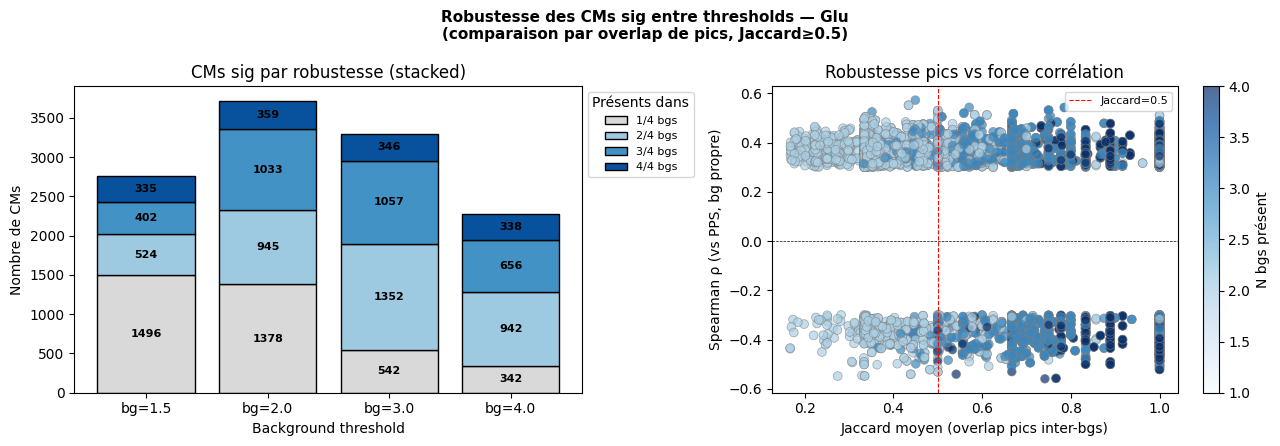

✅ Sauvegardé → ../data/processed/results_aCM_AD_Glu/cms_threshold_overlap.csv & .png

=== Gaba ===
Total entrées CM_bg: 8013 (un CM peut apparaître dans plusieurs bgs)

Robustesse (Jaccard ≥ 0.5):
  4/4 bgs : 832 CM_bg ← robustes (tous bgs)
  3/4 bgs : 1632 CM_bg 
  2/4 bgs : 2480 CM_bg 
  1/4 bgs : 3069 CM_bg 

CM_bg robustes (présents dans les 4 bgs, Jaccard≥0.5): 832


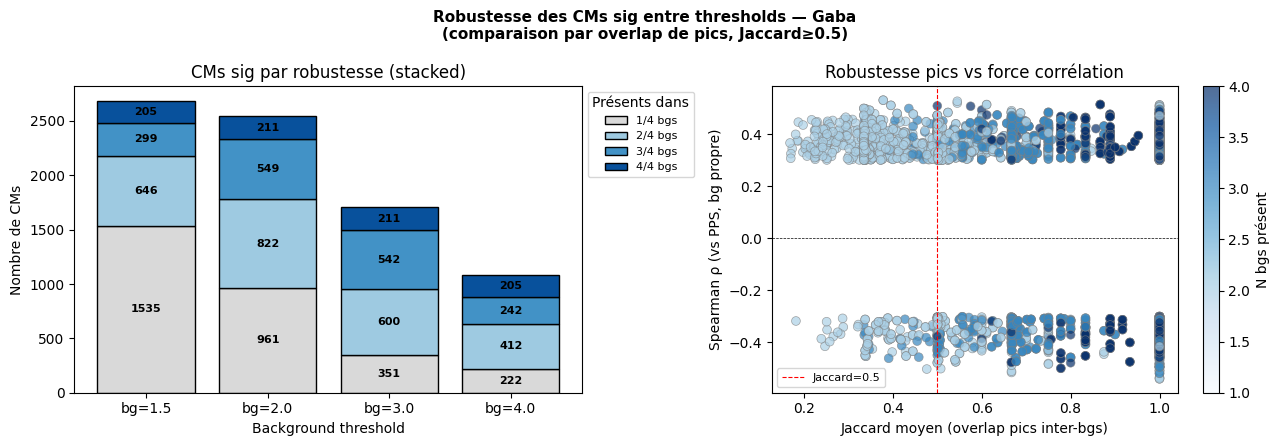

✅ Sauvegardé → ../data/processed/results_aCM_AD_Gaba/cms_threshold_overlap.csv & .png


In [17]:

JACCARD_MIN = 0.5

all_membership = {}

for cell_type, cfg in CELL_TYPES.items():
    out_dir  = cfg['out_dir']
    cm_peaks = all_cm_peaks[cell_type]
    sig_cms  = all_sig_cms[cell_type]
    bgs      = sorted(sig_cms.keys())  # [1.5, 2, 3, 4]

    if len(bgs) < 2:
        print(f"{cell_type}: pas assez de thresholds pour comparer")
        continue

    # Sets de pics par CM_bg (clé = "CM_X_bgY")
    peak_sets = {k: set(v) for k, v in cm_peaks.items()}

    # Liste des CM_bg par threshold
    cms_per_bg = {bg: [k for k in cm_peaks if k.endswith(f'_bg{bg}')] for bg in bgs}

    # Pour chaque CM_bg, chercher le meilleur match (Jaccard) dans chaque autre bg
    records = []
    for bg_ref in bgs:
        for cm_ref in cms_per_bg.get(bg_ref, []):
            peaks_ref = peak_sets[cm_ref]
            cm_id     = cm_ref.rsplit(f'_bg{bg_ref}', 1)[0]
            corr      = sig_cms[bg_ref].loc[cm_id] if cm_id in sig_cms[bg_ref].index else None
            row = {
                'CM_bg':   cm_ref,
                'CM':      cm_id,
                'bg':      bg_ref,
                'n_peaks': len(peaks_ref),
                'rho':     corr['rho']  if corr is not None else np.nan,
                'padj':    corr['padj'] if corr is not None else np.nan,
            }
            for bg_other in bgs:
                if bg_other == bg_ref:
                    continue
                best_j, best_cm = 0.0, None
                for cm_other in cms_per_bg.get(bg_other, []):
                    peaks_other = peak_sets[cm_other]
                    union = peaks_ref | peaks_other
                    if not union:
                        continue
                    j = len(peaks_ref & peaks_other) / len(union)
                    if j > best_j:
                        best_j, best_cm = j, cm_other
                row[f'match_bg{bg_other}'] = best_cm if best_j >= JACCARD_MIN else None
                row[f'jaccard_bg{bg_other}'] = round(best_j, 3)
            records.append(row)

    df = pd.DataFrame(records)

    # Nombre de bgs où ce CM a un équivalent (lui-même + bgs avec match)
    match_cols = [c for c in df.columns if c.startswith('match_bg')]
    df['n_bgs_present'] = df[match_cols].notna().sum(axis=1) + 1  # +1 pour son propre bg

    all_membership[cell_type] = df
    df.to_csv(f'{out_dir}/cms_threshold_overlap.csv', index=False)

    # --- Résumé textuel ---
    print(f"\n{'='*55}\n=== {cell_type} ===")
    print(f"Total entrées CM_bg: {len(df)} (un CM peut apparaître dans plusieurs bgs)")
    print(f"\nRobustesse (Jaccard ≥ {JACCARD_MIN}):")
    for n in sorted(df['n_bgs_present'].unique(), reverse=True):
        label = '← robustes (tous bgs)' if n == len(bgs) else ''
        count = (df['n_bgs_present'] == n).sum()
        print(f"  {n}/{len(bgs)} bgs : {count} CM_bg {label}")

    robust = df[df['n_bgs_present'] == len(bgs)][['CM_bg', 'bg', 'rho', 'padj', 'n_peaks'] + [f'jaccard_bg{b}' for b in bgs if f'jaccard_bg{b}' in df.columns]]
    print(f"\nCM_bg robustes (présents dans les {len(bgs)} bgs, Jaccard≥{JACCARD_MIN}): {len(robust)}")
    if 0 < len(robust) <= 30:
        print(robust.to_string(index=False))

    # --- Figure ---
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.suptitle(f'Robustesse des CMs sig entre thresholds — {cell_type}\n(comparaison par overlap de pics, Jaccard≥{JACCARD_MIN})',
                 fontweight='bold', fontsize=11)

    # Barplot robustesse
    dist = df.groupby('bg')['n_bgs_present'].value_counts().unstack(fill_value=0)
    dist = dist.reindex(columns=range(1, len(bgs)+1), fill_value=0)
    colors_bar = ['#d9d9d9', '#9ecae1', '#4292c6', '#08519c']
    bottom = np.zeros(len(bgs))
    for k, col in enumerate(dist.columns):
        vals = dist[col].values
        bars = axes[0].bar([f'bg={b}' for b in dist.index], vals,
                           bottom=bottom, color=colors_bar[k % len(colors_bar)],
                           edgecolor='black', label=f'{col}/{len(bgs)} bgs')
        for bar, v, bot in zip(bars, vals, bottom):
            if v > 0:
                axes[0].text(bar.get_x() + bar.get_width()/2, bot + v/2,
                             str(v), ha='center', va='center', fontsize=8, fontweight='bold')
        bottom += vals
    axes[0].set_xlabel('Background threshold')
    axes[0].set_ylabel('Nombre de CMs')
    axes[0].set_title('CMs sig par robustesse (stacked)')
    axes[0].legend(title='Présents dans', bbox_to_anchor=(1, 1), loc='upper left', fontsize=8)

    # Scatter Jaccard moyen vs rho (pour les CMs présents dans ≥ 2 bgs)
    jaccard_cols = [c for c in df.columns if c.startswith('jaccard_bg')]
    df['mean_jaccard'] = df[jaccard_cols].replace(0, np.nan).mean(axis=1)
    subset = df[df['n_bgs_present'] >= 2].dropna(subset=['mean_jaccard', 'rho'])
    if len(subset) > 0:
        sc = axes[1].scatter(subset['mean_jaccard'], subset['rho'],
                             c=subset['n_bgs_present'], cmap='Blues',
                             vmin=1, vmax=len(bgs), s=40, alpha=0.7, edgecolors='grey', lw=0.5)
        plt.colorbar(sc, ax=axes[1], label='N bgs présent')
        axes[1].axhline(0, color='black', lw=0.5, ls='--')
        axes[1].axvline(JACCARD_MIN, color='red', lw=0.8, ls='--', label=f'Jaccard={JACCARD_MIN}')
        axes[1].set_xlabel('Jaccard moyen (overlap pics inter-bgs)')
        axes[1].set_ylabel('Spearman ρ (vs PPS, bg propre)')
        axes[1].set_title('Robustesse pics vs force corrélation')
        axes[1].legend(fontsize=8)
    else:
        axes[1].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'{out_dir}/cms_threshold_overlap.png', dpi=150)
    plt.show()
    print(f"✅ Sauvegardé → {out_dir}/cms_threshold_overlap.csv & .png")
